In [247]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, acovf, pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option('display.precision', 3)

# Import Data
**Unit**: $\mu g/m^3$

In [248]:
data = pd.read_csv("bangkok-air-quality.csv")
data = data.drop(data.columns[-2:], axis=1)
data['date'] = pd.to_datetime(data['date'])
data = data.dropna().reset_index(drop=True)
items = data.columns[1:]

In [249]:
data[:10]

,date,pm25,pm10,o3,no2
0,2026-05-01,77.0,30.0,22.0,4.0
1,2026-05-02,76.0,35.0,17.0,4.0
2,2026-05-03,64.0,31.0,20.0,5.0
3,2026-05-04,64.0,24.0,35.0,9.0
4,2026-05-05,62.0,29.0,27.0,10.0
5,2026-05-06,76.0,27.0,17.0,7.0
6,2026-05-07,72.0,27.0,27.0,12.0
7,2026-05-08,74.0,31.0,29.0,12.0
8,2026-05-09,89.0,27.0,27.0,10.0
9,2026-05-10,78.0,27.0,23.0,8.0


In [250]:
data.describe().drop('date', axis=1)

,pm25,pm10,o3,no2
count,3222.000,3222.000,3222.000,3222.000
mean,83.510,41.192,15.525,9.604
min,13.000,5.000,1.000,1.000
25%,61.000,27.000,9.000,5.000
50%,76.000,37.000,14.000,8.000
75%,101.000,51.000,20.000,13.000
max,187.000,528.000,94.000,39.000
std,30.775,24.890,8.032,6.414


<Axes: >

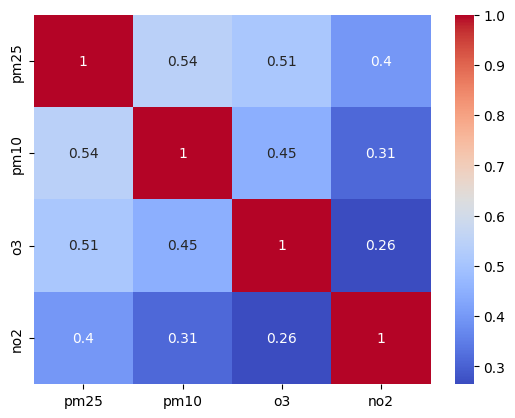

In [251]:
corr = data.drop('date', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

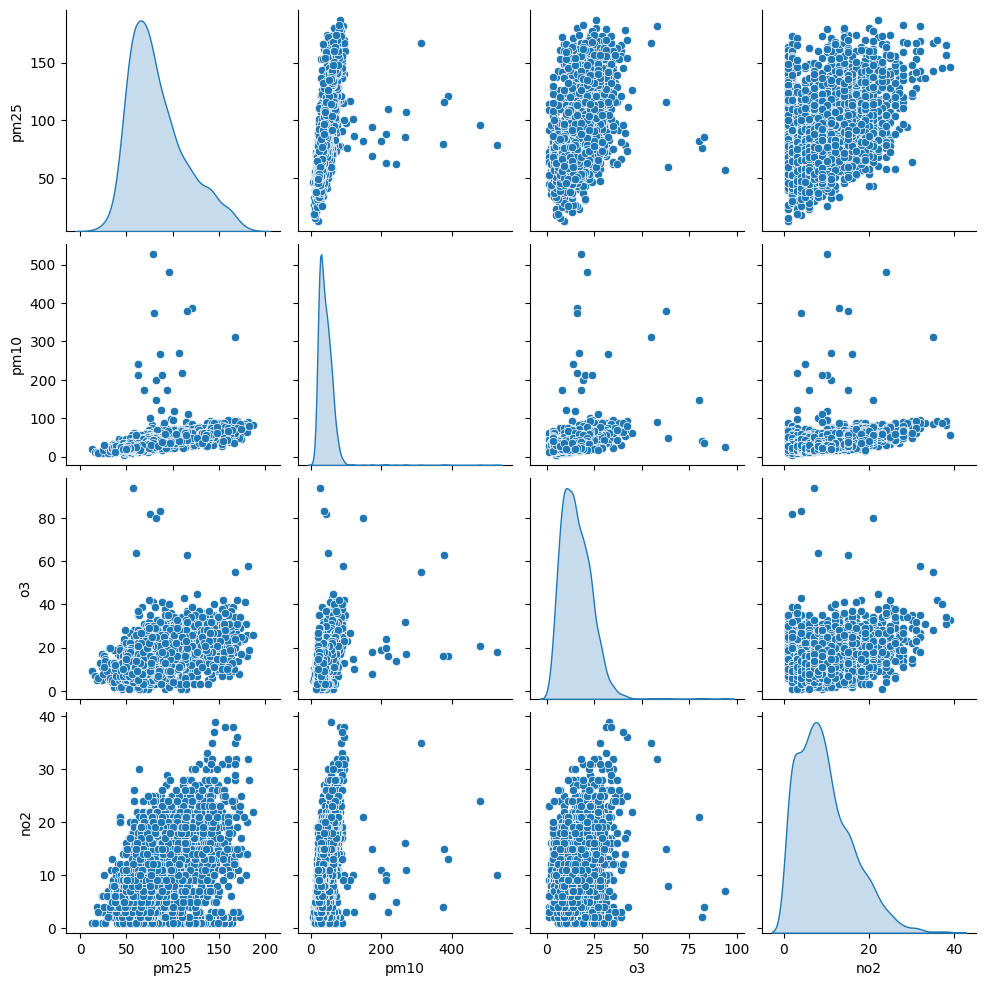

In [252]:
sns.pairplot(data.drop('date', axis=1), diag_kind='kde')

# Find Autocorrelation

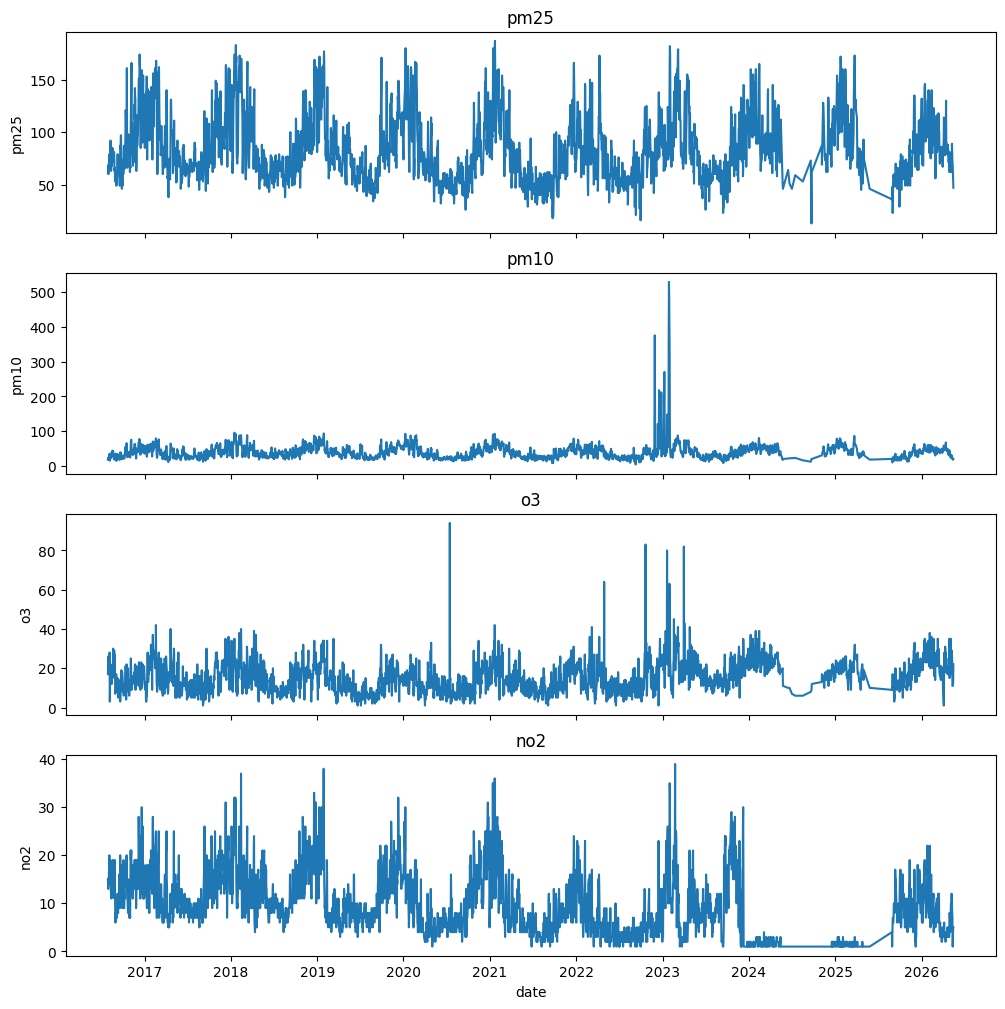

In [253]:
fig, axs = plt.subplots(len(items), 1, figsize=(12, 3*len(items)), sharex=True)
for i, item in enumerate(items):
    sns.lineplot(x='date', y=item, data=data, ax=axs[i])
    axs[i].set_title(item)

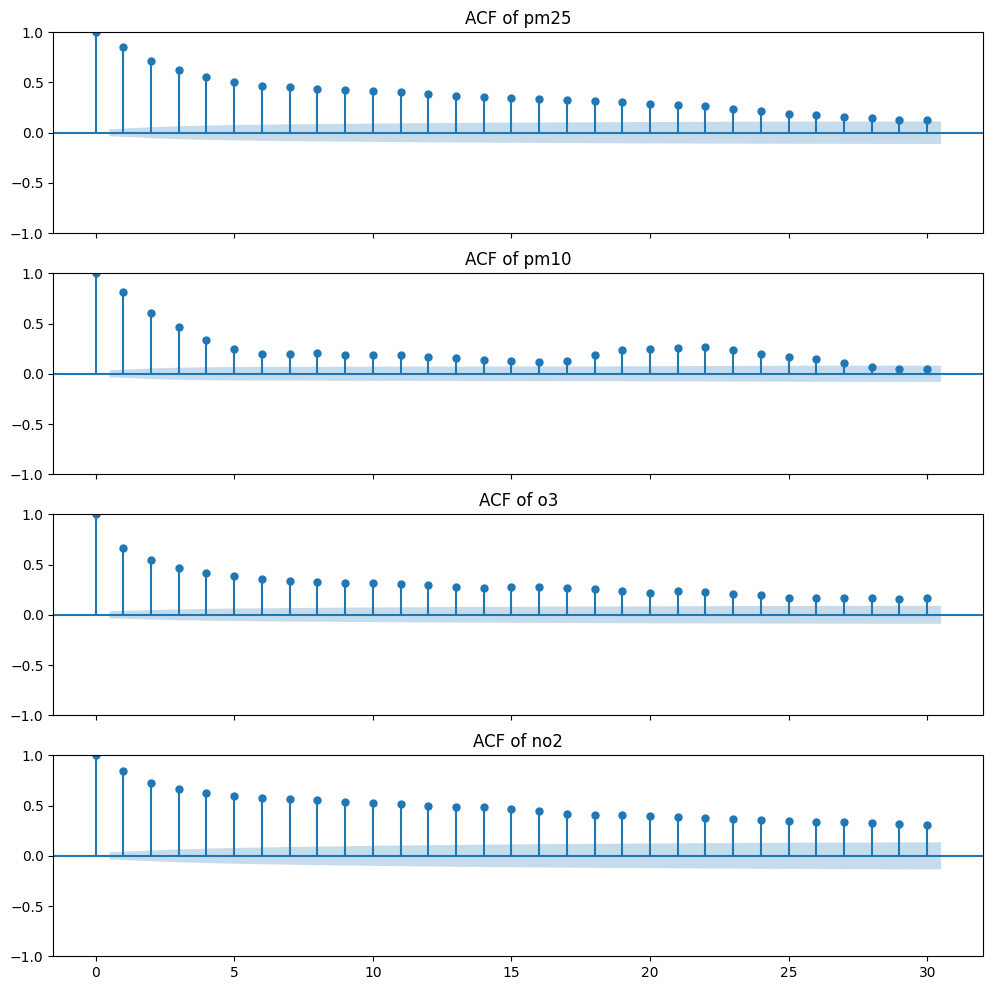

In [254]:
fig, axs = plt.subplots(len(items), 1, figsize=(12, 3*len(items)), sharex=True)
for i, item in enumerate(items):
    plot_acf(data[item], lags=30,alpha=0.05, title=f'ACF of {item}', ax=axs[i])
plt.show()

# Boxplots

## Display boxplots by year

Text(0.5, 0, 'Year')

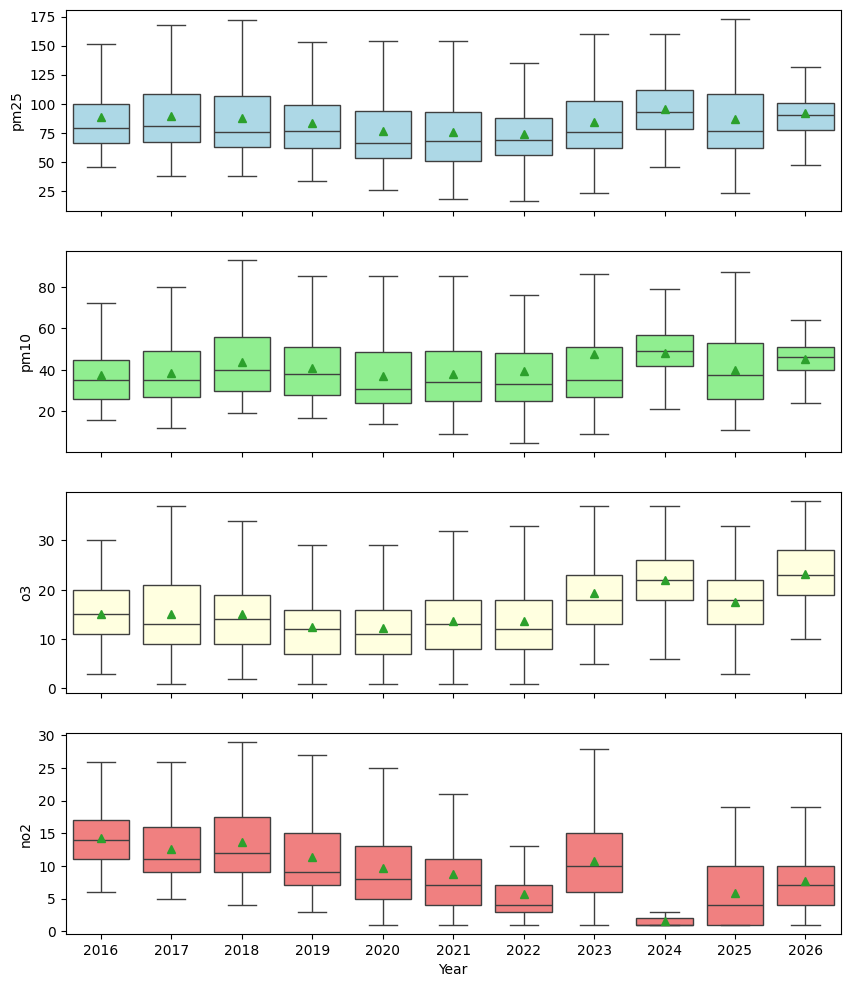

In [264]:
fig, axes = plt.subplots(4, 1, figsize=(10, 3*4),sharex=True)

sns.boxplot(x=data['date'].dt.year, y=data['pm25'], ax=axes[0], showfliers=False, showmeans=True, boxprops={'facecolor':'lightblue'})
sns.boxplot(x=data['date'].dt.year, y=data['pm10'], ax=axes[1], showfliers=False, showmeans=True, boxprops={'facecolor':'lightgreen'})
sns.boxplot(x=data['date'].dt.year, y=data['o3'], ax=axes[2], showfliers=False, showmeans=True, boxprops={'facecolor':'lightyellow'})
sns.boxplot(x=data['date'].dt.year, y=data['no2'], ax= axes[3], showfliers=False, showmeans=True, boxprops={'facecolor':'lightcoral'})
plt.xlabel("Year")

## Display boxplots by month

Text(0.5, 0, 'Month')

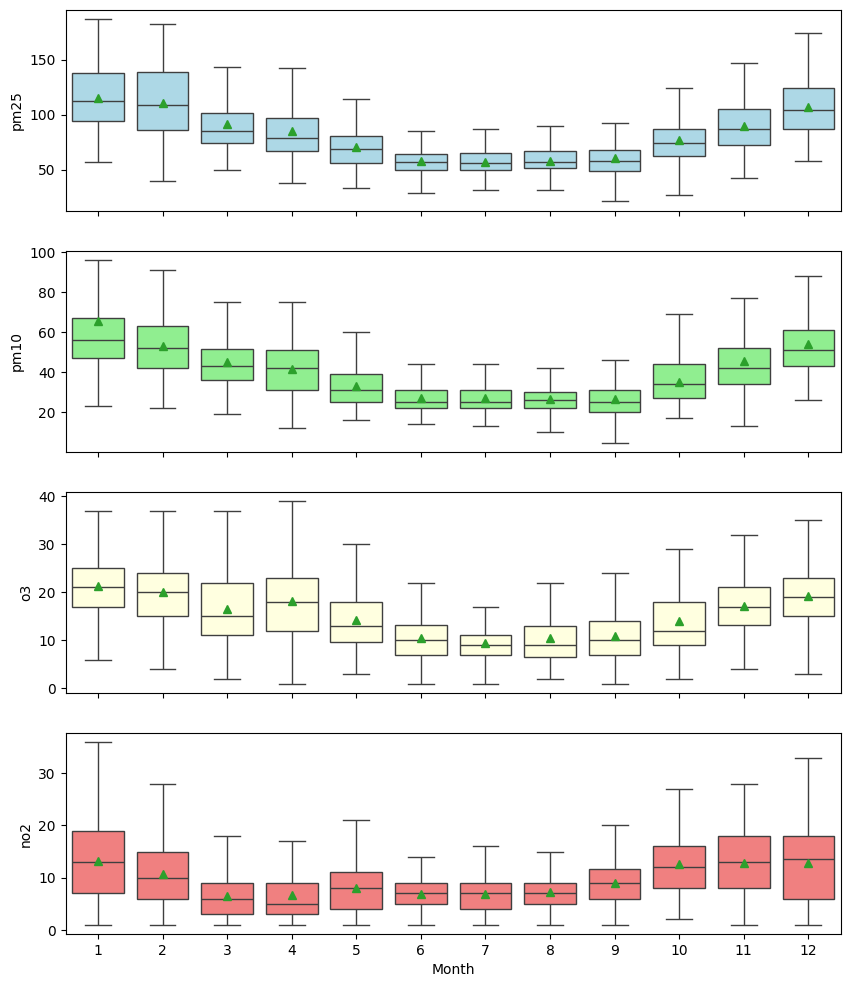

In [263]:
fig, axes = plt.subplots(4, 1, figsize=(10, 3*4),sharex=True)

sns.boxplot(x=data['date'].dt.month, y=data['pm25'], ax=axes[0], showfliers=False, showmeans=True, boxprops={'facecolor':'lightblue'})
sns.boxplot(x=data['date'].dt.month, y=data['pm10'], ax=axes[1], showfliers=False, showmeans=True, boxprops={'facecolor':'lightgreen'})
sns.boxplot(x=data['date'].dt.month, y=data['o3'], ax=axes[2], showfliers=False, showmeans=True, boxprops={'facecolor':'lightyellow'})
sns.boxplot(x=data['date'].dt.month, y=data['no2'], ax= axes[3], showfliers=False, showmeans=True, boxprops={'facecolor':'lightcoral'})
plt.xlabel("Month")

## Display histograms and boxplots of PM2.5 by quarter

Text(0.5, 0.98, 'PM2.5 Distribution by Quarter')

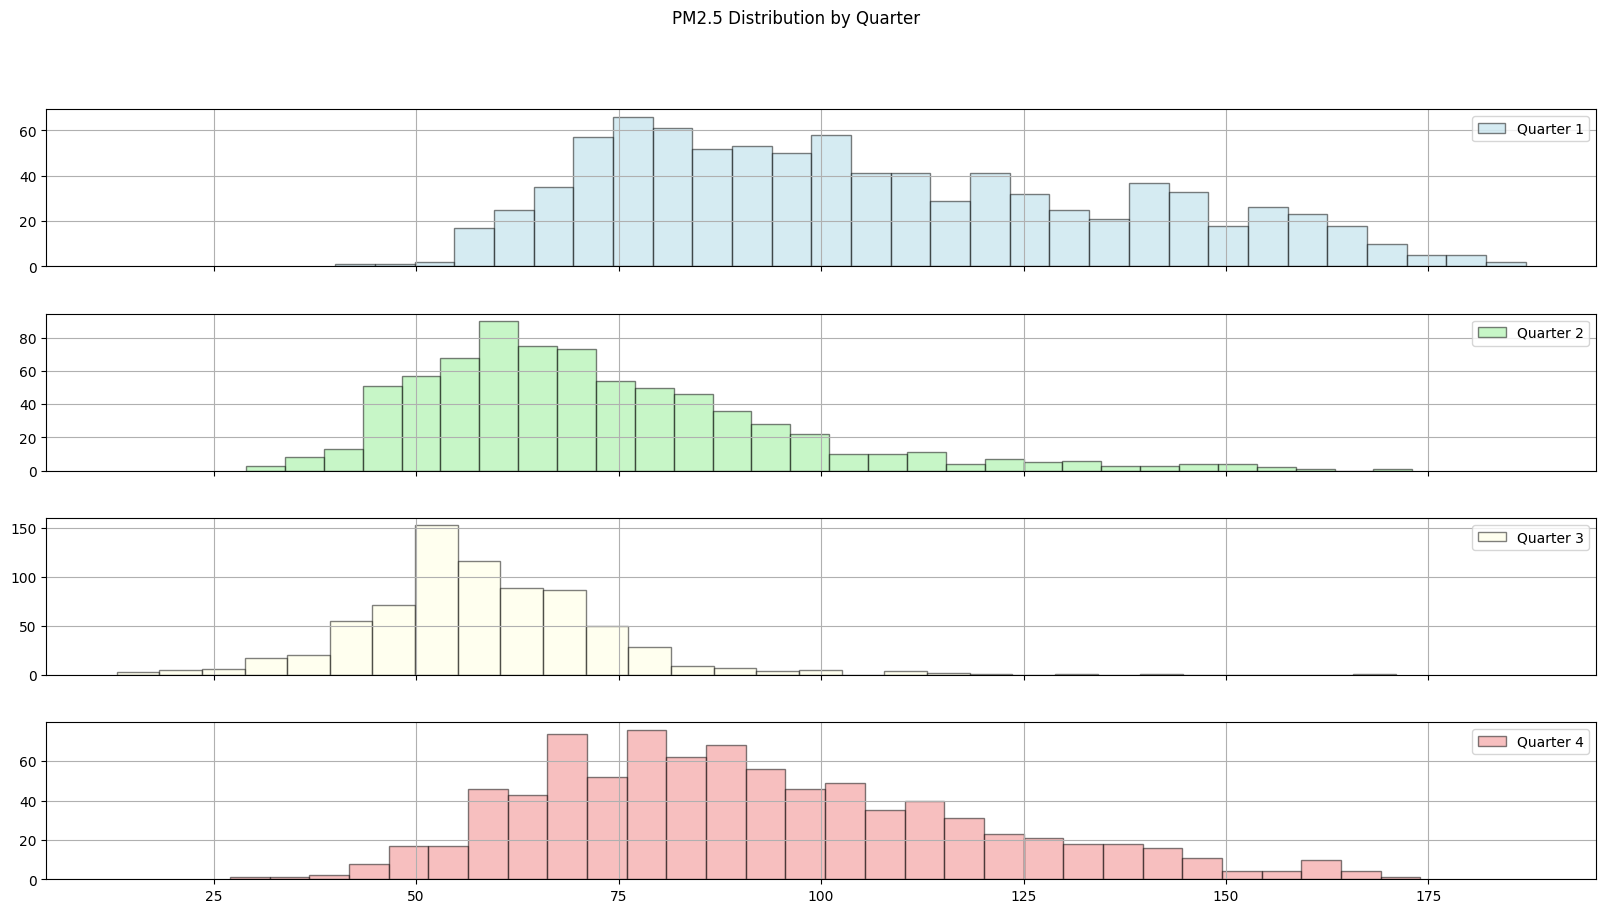

In [257]:
fig, axs = plt.subplots(4,1, figsize=(20,10), sharex=True)

colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']

for quarter, group in data.groupby(data['date'].dt.quarter):
    group.hist("pm25", bins=30, color=colors[quarter-1], edgecolor='black', ax=axs[quarter-1], label=f"Quarter {quarter}",alpha=0.5)
    axs[quarter-1].set_title(None)
    axs[quarter-1].legend()

fig.suptitle("PM2.5 Distribution by Quarter")

Text(0.5, 0, 'Quarter')

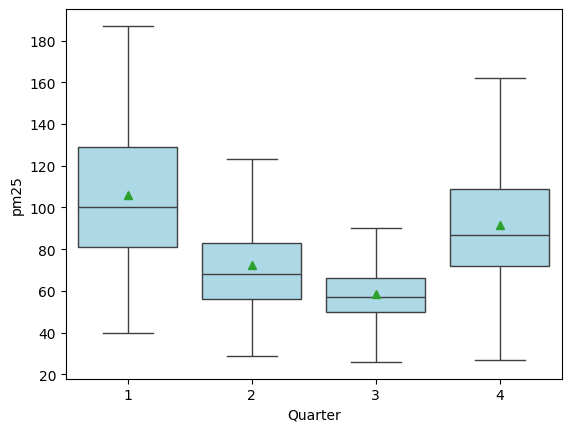

In [258]:
fig, ax = plt.subplots(1, 1)

sns.boxplot(x=data['date'].dt.quarter, y=data['pm25'], ax=ax, showfliers=False, showmeans=True, boxprops={'facecolor':'lightblue'})
plt.xlabel("Quarter")

## Display histograms and boxplots of PM2.5 by Seasons

Text(0.5, 0.98, 'PM2.5 Distribution by Season')

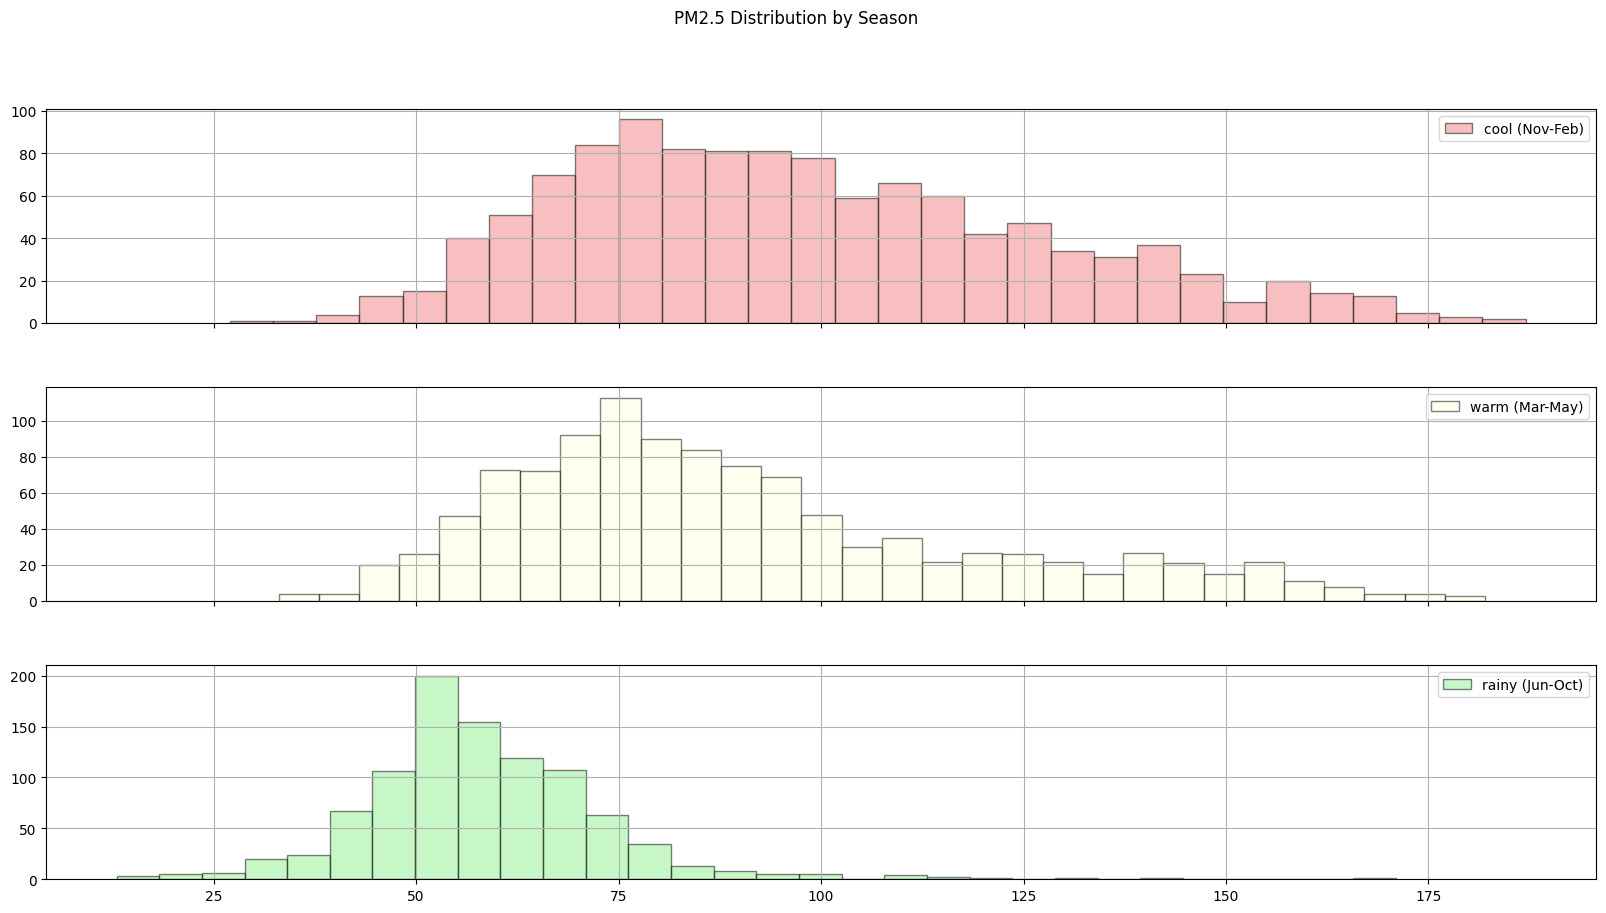

In [ ]:
fig, axs = plt.subplots(3,1, figsize=(20,10), sharex=True)

colors = ['lightcoral', 'lightyellow', 'lightgreen']
get_season = lambda month: 1 if month in [11, 12, 1, 2] else 2 if month in [3, 4, 5] else 3
seasons = ["cool (Nov-Feb)", "warm (Mar-May)", "rainy (Jun-Oct)"]

for season, group in data.groupby(data.date.map(get_season)):
    group.hist("pm25", bins=30, color=colors[season-1], edgecolor='black', ax=axs[season-1], label=f"{seasons[season-1]}",alpha=0.5)
    axs[season-1].set_title(None)
    axs[season-1].legend()

fig.suptitle("PM2.5 Distribution by Season")

Text(0.5, 0, 'Season')

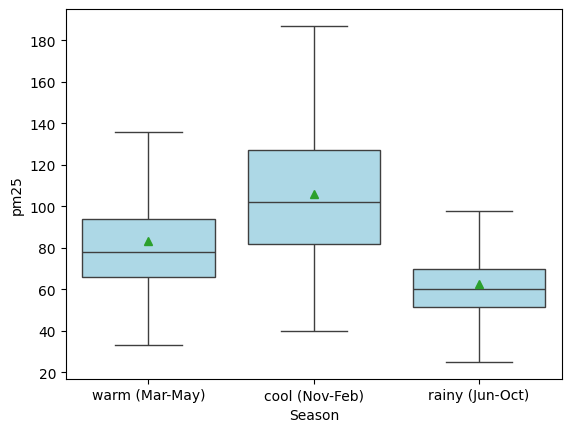

In [260]:
fig, ax = plt.subplots(1,1)

seasons = ["cool (Nov-Feb)", "warm (Mar-May)", "rainy (Jun-Oct)"]
grouped_by_season = data.date.map(lambda x: seasons[0] if x.month in [11, 12, 1, 2] else seasons[1] if x.month in [3, 4, 5] else seasons[2])

sns.boxplot(x=grouped_by_season, y=data['pm25'], ax=ax, showfliers=False, showmeans=True, boxprops={'facecolor':'lightblue'})
plt.xlabel("Season")

# Time series decomposition

In [267]:
results = seasonal_decompose(data['pm25'], model='additive', period=365)
trend = results.trend
seasonal = results.seasonal
resid = results.resid

<Axes: xlabel='date', ylabel='resid'>

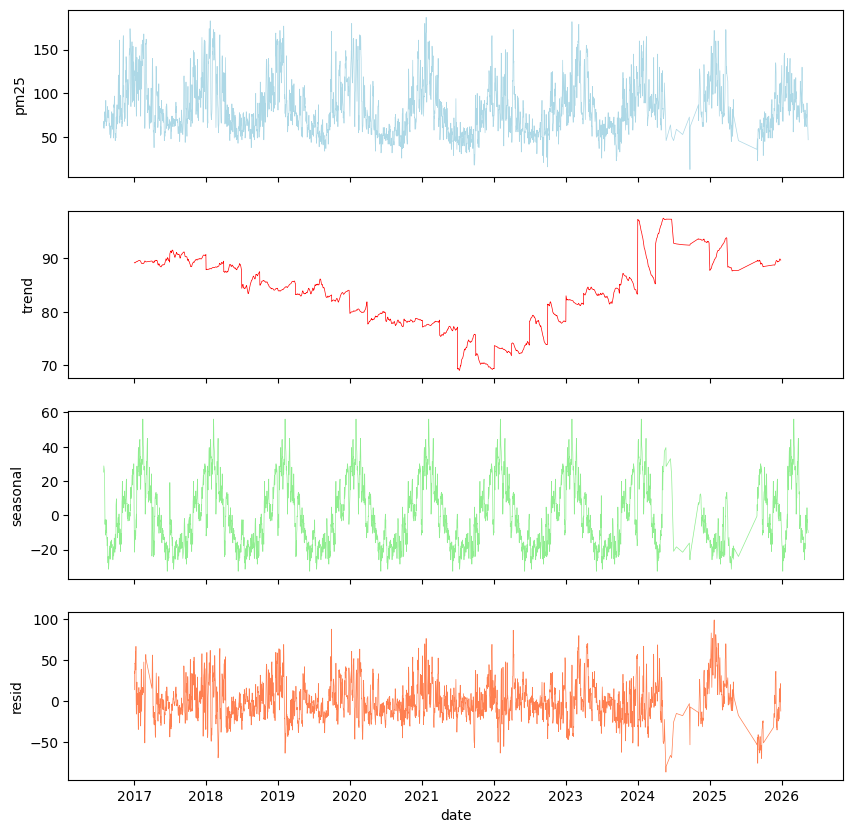

In [268]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

sns.lineplot(x=data['date'], y=data['pm25'], ax=axes[0], linewidth=0.5,color='lightblue')
sns.lineplot(x=data['date'], y=trend, ax=axes[1], linewidth=0.5,color='red')
sns.lineplot(x=data['date'], y=seasonal, ax=axes[2], linewidth=0.5,color='lightgreen')
sns.lineplot(x=data['date'], y=resid, ax=axes[3], linewidth=0.5,color='coral')